Kaggle Dataset

In [1]:
!kaggle datasets download -d dmitrybabko/speech-emotion-recognition-en
!unzip speech-emotion-recognition-en.zip

Streaming output truncated to the last 5000 lines.
  inflating: Crema/1088_IWW_FEA_XX.wav  
  inflating: Crema/1088_IWW_HAP_XX.wav  
  inflating: Crema/1088_IWW_NEU_XX.wav  
  inflating: Crema/1088_IWW_SAD_XX.wav  
  inflating: Crema/1088_MTI_ANG_XX.wav  
  inflating: Crema/1088_MTI_DIS_XX.wav  
  inflating: Crema/1088_MTI_FEA_XX.wav  
  inflating: Crema/1088_MTI_HAP_XX.wav  
  inflating: Crema/1088_MTI_NEU_XX.wav  
  inflating: Crema/1088_MTI_SAD_XX.wav  
  inflating: Crema/1088_TAI_ANG_XX.wav  
  inflating: Crema/1088_TAI_DIS_XX.wav  
  inflating: Crema/1088_TAI_FEA_XX.wav  
  inflating: Crema/1088_TAI_HAP_XX.wav  
  inflating: Crema/1088_TAI_NEU_XX.wav  
  inflating: Crema/1088_TAI_SAD_XX.wav  
  inflating: Crema/1088_TIE_ANG_XX.wav  
  inflating: Crema/1088_TIE_DIS_XX.wav  
  inflating: Crema/1088_TIE_FEA_XX.wav  
  inflating: Crema/1088_TIE_HAP_XX.wav  
  inflating: Crema/1088_TIE_NEU_XX.wav  
  inflating: Crema/1088_TIE_SAD_XX.wav  
  inflating: Crema/1088_TSI_ANG_XX.wav  
  infl

Load Data

In [6]:
import os
import pandas as pd

data_path = 'Crema/'

# 2. Level 1 Audit: List all files and parse emotions
audio_files = []
for file in os.listdir(data_path):
    if file.endswith(".wav"):
        # Filename example: 1001_DFA_ANG_XX.wav
        parts = file.split('_')
        if len(parts) >= 3:
            audio_files.append({
                'filename': file,
                'actor_id': parts[0],  # This is our "Group" for the split
                'emotion': parts[2],   # This is our "Target" (ANG, HAP, etc.)
                'path': os.path.join(data_path, file)
            })

df = pd.DataFrame(audio_files)

# --- AUDIT OUTPUT ---
print(f"Total Files Found: {len(df)}")
print("\nUnique Emotions (Class Balance):")
print(df['emotion'].value_counts())

print("\nUnique Actors (For Group Split):")
print(f"Total Actors: {df['actor_id'].nunique()}")

df.head()

Total Files Found: 7442

Unique Emotions (Class Balance):
emotion
HAP    1271
FEA    1271
SAD    1271
DIS    1271
ANG    1271
NEU    1087
Name: count, dtype: int64

Unique Actors (For Group Split):
Total Actors: 91


,filename,actor_id,emotion,path
0,1073_DFA_NEU_XX.wav,1073,NEU,Crema/1073_DFA_NEU_XX.wav
1,1070_ITH_HAP_XX.wav,1070,HAP,Crema/1070_ITH_HAP_XX.wav
2,1034_IEO_HAP_LO.wav,1034,HAP,Crema/1034_IEO_HAP_LO.wav
3,1045_MTI_FEA_XX.wav,1045,FEA,Crema/1045_MTI_FEA_XX.wav
4,1064_ITH_DIS_XX.wav,1064,DIS,Crema/1064_ITH_DIS_XX.wav


Split and Extract Features

In [13]:
!pip install --upgrade librosa numba soundfile audioread resampy

In [14]:
import librosa
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

print("--- LEVEL 2: STARTING FEATURE EXTRACTION ---")

# 1.Group Split
unique_actors = df['actor_id'].unique()
train_actors, temp_actors = train_test_split(unique_actors, test_size=0.30, random_state=42)
val_actors, test_actors = train_test_split(temp_actors, test_size=0.50, random_state=42)

def extract_features(file_path):
    try:
        # Simplified load
        # Using default 'sr=None' to keep original then resampling manually if needed
        # Or just stick to 22050 without the kaiser_fast flag
        audio, sr = librosa.load(file_path, duration=3.0, sr=22050)

        # Padding/Trimming
        if len(audio) < 66150:
            audio = np.pad(audio, (0, 66150 - len(audio)), 'constant')
        else:
            audio = audio[:66150]

        # MFCC Extraction
        mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
        return np.mean(mfccs.T, axis=0)
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None

# 2. Extract features only for Train and Val
print("Extracting features (This takes 2-5 minutes)...")

# Process Train
train_data = df[df['actor_id'].isin(train_actors)]
X_train = []
for p in train_data['path']:
    feat = extract_features(p)
    if feat is not None: X_train.append(feat)
X_train = np.array(X_train)
y_train = train_data['emotion'][:len(X_train)]

# Process Val
val_data = df[df['actor_id'].isin(val_actors)]
X_val = []
for p in val_data['path']:
    feat = extract_features(p)
    if feat is not None: X_val.append(feat)
X_val = np.array(X_val)
y_val = val_data['emotion'][:len(X_val)]

# 3. Label Encoding
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)
y_val_encoded = encoder.transform(y_val)

print("\n--- LEVEL 2 SUCCESS ---")
print(f"X_train Shape: {X_train.shape}")
print(f"X_val Shape: {X_val.shape}")
print(f"Emotions encoded: {list(encoder.classes_)}")

--- LEVEL 2: RE-STARTING FEATURE EXTRACTION ---
Extracting features (This takes 2-5 minutes)...

--- LEVEL 2 SUCCESS ---
X_train Shape: (5154, 40)
X_val Shape: (1148, 40)
Emotions encoded: ['ANG', 'DIS', 'FEA', 'HAP', 'NEU', 'SAD']


Model Selection & Training

In [16]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("--- LEVEL 3: TRAINING THE NEURAL NETWORK (MLP) ---")

# 1. Define the Model
mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    batch_size=32,
    learning_rate_init=0.001,
    max_iter=300,
    random_state=42,
    verbose=True # Shows progress during training
)

# 2. Train the Model
mlp.fit(X_train, y_train_encoded)

--- LEVEL 3: TRAINING THE NEURAL NETWORK (MLP) ---
Iteration 1, loss = 3.52502609
Iteration 2, loss = 2.43788722
Iteration 3, loss = 2.21803928
Iteration 4, loss = 2.12114159
Iteration 5, loss = 2.18146670
Iteration 6, loss = 1.94459841
Iteration 7, loss = 2.09923656
Iteration 8, loss = 1.74256675
Iteration 9, loss = 1.78412394
Iteration 10, loss = 1.83104200
Iteration 11, loss = 1.77536992
Iteration 12, loss = 1.69748188
Iteration 13, loss = 1.73712726
Iteration 14, loss = 1.66592574
Iteration 15, loss = 1.63737210
Iteration 16, loss = 1.68010990
Iteration 17, loss = 1.53757320
Iteration 18, loss = 1.52059526
Iteration 19, loss = 1.49454991
Iteration 20, loss = 1.52997625
Iteration 21, loss = 1.43758029
Iteration 22, loss = 1.50758089
Iteration 23, loss = 1.43428287
Iteration 24, loss = 1.42836411
Iteration 25, loss = 1.41762809
Iteration 26, loss = 1.44014231
Iteration 27, loss = 1.43627939
Iteration 28, loss = 1.41724293
Iteration 29, loss = 1.37862377
Iteration 30, loss = 1.3644429

MLPClassifier(batch_size=32, hidden_layer_sizes=(256, 128), max_iter=300,
              random_state=42, verbose=True)

Evaluation


--- LEVEL 3: EVALUATION ---
              precision    recall  f1-score   support

         ANG       0.52      0.60      0.56       196
         DIS       0.38      0.27      0.31       196
         FEA       0.34      0.36      0.35       196
         HAP       0.32      0.44      0.37       196
         NEU       0.36      0.20      0.26       168
         SAD       0.47      0.51      0.49       196

    accuracy                           0.40      1148
   macro avg       0.40      0.40      0.39      1148
weighted avg       0.40      0.40      0.39      1148



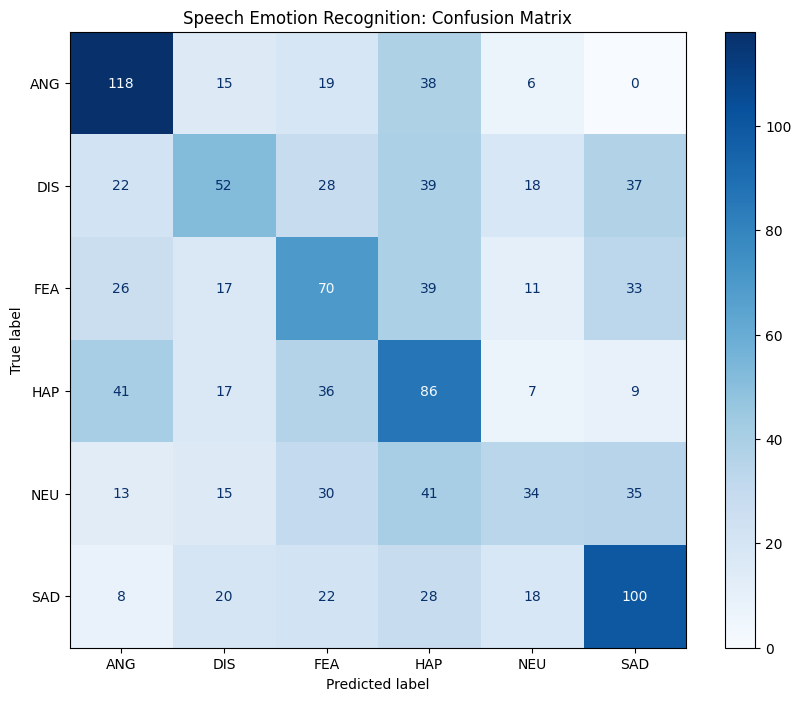

In [18]:
print("\n--- LEVEL 3: EVALUATION ---")

# 3. Predict on Validation Set
y_pred = mlp.predict(X_val)

# 4. Generate Classification Report (Precision, Recall, F1)
print(classification_report(y_val_encoded, y_pred, target_names=encoder.classes_))

# 5. Plot Confusion Matrix
cm = confusion_matrix(y_val_encoded, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=encoder.classes_)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(cmap='Blues', ax=ax)
plt.title("Speech Emotion Recognition: Confusion Matrix")
plt.show()

Level 4 Feature Extraction (The 2D Version)

In [19]:
def extract_features_2d(file_path):
    audio, sr = librosa.load(file_path, duration=3.0, sr=22050)
    if len(audio) < 66150:
        audio = np.pad(audio, (0, 66150 - len(audio)), 'constant')
    else:
        audio = audio[:66150]

    # NOTICE: No 'np.mean' here! We keep the full matrix
    mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
    return mfccs

# Re-extracting for a small sample to show you the shape
# This will turn (40,) into (40, 129) - like a 40x129 pixel image
print("Preparing 2D Data for CNN...")
X_train_2d = np.array([extract_features_2d(p) for p in train_data['path']])
X_val_2d = np.array([extract_features_2d(p) for p in val_data['path']])

# CNNs expect a "Channel" dimension (like Color in images)
X_train_2d = X_train_2d[..., np.newaxis]
X_val_2d = X_val_2d[..., np.newaxis]

print(f"New CNN Input Shape: {X_train_2d.shape}") # Should be (Samples, 40, 130, 1)

Preparing 2D Data for CNN...
New CNN Input Shape: (5154, 40, 130, 1)


Building the CNN

In [20]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    # Layer 1: Look for small patterns in the MFCCs
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(40, 130, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2), # Regularisation to stop overfitting

    # Layer 2: Combine those patterns
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),

    # Final Dense Layers
    layers.Dense(64, activation='relu'),
    layers.Dense(6, activation='softmax') # 6 Emotions
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 38, 128, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 19, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 19, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 17, 62, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 31, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 15872)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,015,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,035,078 (3.95 MB)

 Trainable params: 1,035,078 (3.95 MB)

 Non-trainable params: 0 (0.00 B)

Deep Learning training

In [22]:
# 1. Update the model slightly to fix the warning and add more regularisation
cnn_model = models.Sequential([
    layers.Input(shape=(40, 130, 1)), # Fixes the UserWarning

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3), # Dropout helps prevent overfitting

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(6, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 2. START THE TRAINING
history = cnn_model.fit(
    X_train_2d, y_train_encoded,
    epochs=15,
    batch_size=16,
    validation_data=(X_val_2d, y_val_encoded),
    verbose=1
)

Epoch 1/15
323/323 ━━━━━━━━━━━━━━━━━━━━ 48s 136ms/step - accuracy: 0.2629 - loss: 2.5179 - val_accuracy: 0.3397 - val_loss: 1.5869
Epoch 2/15
323/323 ━━━━━━━━━━━━━━━━━━━━ 36s 111ms/step - accuracy: 0.3242 - loss: 1.6040 - val_accuracy: 0.3859 - val_loss: 1.5328
Epoch 3/15
323/323 ━━━━━━━━━━━━━━━━━━━━ 42s 115ms/step - accuracy: 0.3523 - loss: 1.5527 - val_accuracy: 0.3754 - val_loss: 1.5161
Epoch 4/15
323/323 ━━━━━━━━━━━━━━━━━━━━ 41s 116ms/step - accuracy: 0.3795 - loss: 1.5072 - val_accuracy: 0.4207 - val_loss: 1.4509
Epoch 5/15
323/323 ━━━━━━━━━━━━━━━━━━━━ 40s 114ms/step - accuracy: 0.4012 - loss: 1.4604 - val_accuracy: 0.4164 - val_loss: 1.5033
Epoch 6/15
323/323 ━━━━━━━━━━━━━━━━━━━━ 36s 110ms/step - accuracy: 0.4059 - loss: 1.4514 - val_accuracy: 0.4216 - val_loss: 1.4814
Epoch 7/15
323/323 ━━━━━━━━━━━━━━━━━━━━ 36s 111ms/step - accuracy: 0.4210 - loss: 1.4151 - val_accuracy: 0.4077 - val_loss: 1.4572
Epoch 8/15
323/323 ━━━━━━━━━━━━━━━━━━━━ 46s 128ms/step - accuracy: 0.4513 - loss: 1

Plot Training vs Validation Accuracy

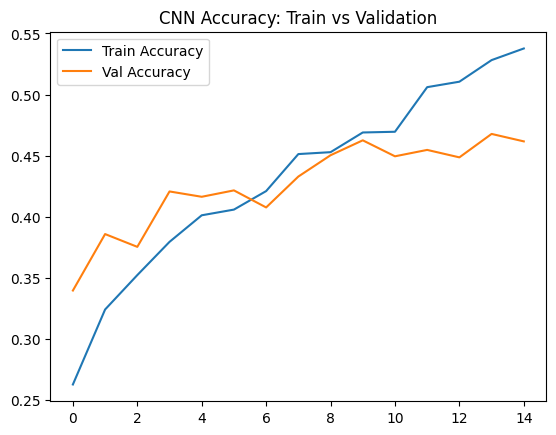

36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.4617 - loss: 1.3806

Final CNN Validation Accuracy: 0.4617


In [23]:
import matplotlib.pyplot as plt

# Plot Training vs Validation Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('CNN Accuracy: Train vs Validation')
plt.legend()
plt.show()

# Final Evaluation
val_loss, val_acc = cnn_model.evaluate(X_val_2d, y_val_encoded)
print(f"\nFinal CNN Validation Accuracy: {val_acc:.4f}")

Model Serialization

In [ ]:
# Save the CNN model
cnn_model.save('speech_emotion_cnn_v1.keras')
print("--- PHASE 12: CNN MODEL SAVED ---")

Error Analysis

36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step


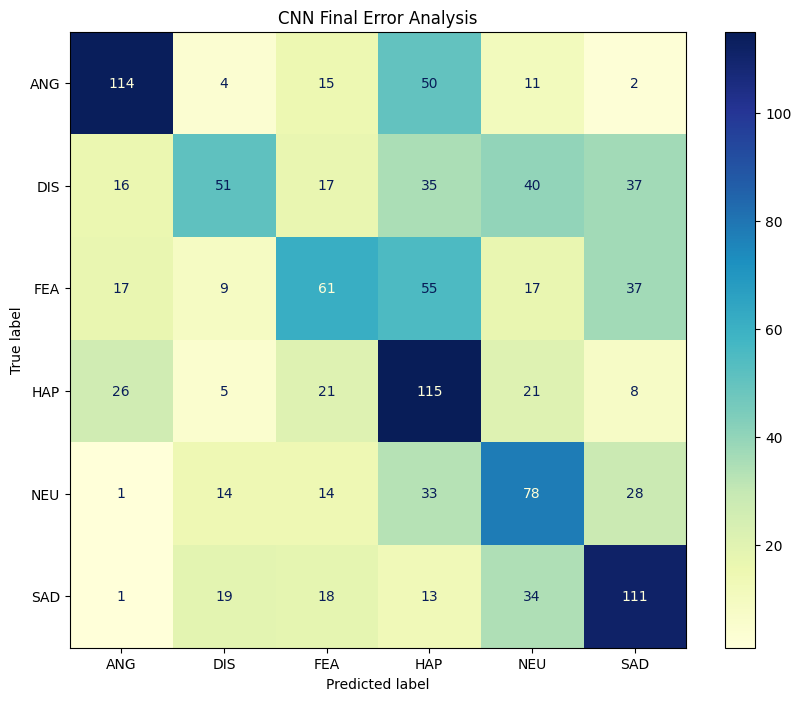

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Get predictions for the Validation set
y_val_pred = np.argmax(cnn_model.predict(X_val_2d), axis=1)

# 2. Plot the Confusion Matrix
cm = confusion_matrix(y_val_encoded, y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=encoder.classes_)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(cmap='YlGnBu', ax=ax)
plt.title("CNN Final Error Analysis")
plt.show()

The Final Test Set Reveal

Preparing Final Test Data for 1140 files...
--- PHASE 11: FINAL PRODUCTION EVALUATION ---
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.4360 - loss: 1.5532

🚀 FINAL PRODUCTION ACCURACY: 0.4360
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step


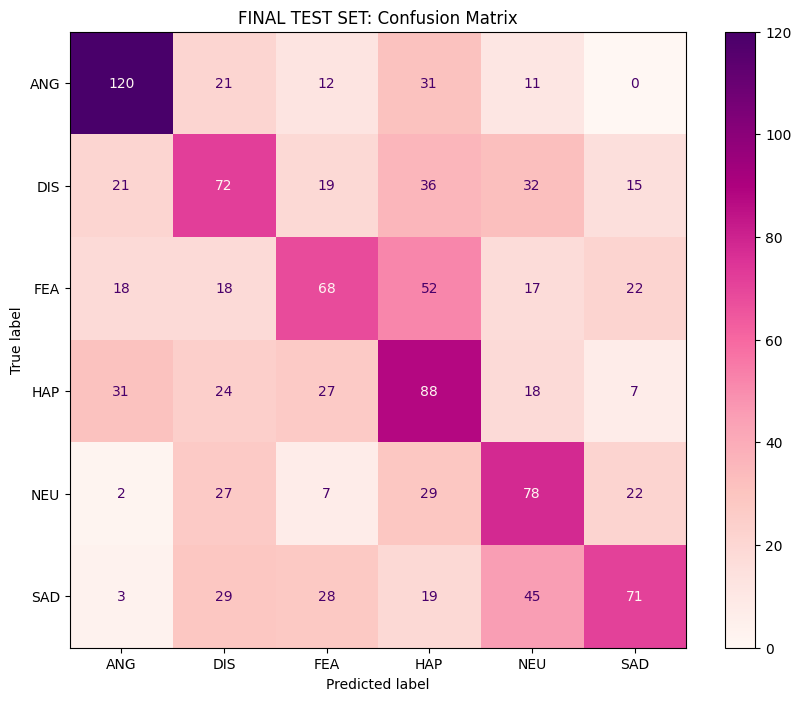

In [27]:
# 1. Create the Test DataFrame from the 'test_actors' we reserved in Level 2
test_df = df[df['actor_id'].isin(test_actors)]

# 2. Level 4: Prepare the 2D Test Features
print(f"Preparing Final Test Data for {len(test_df)} files...")
X_test_2d = np.array([extract_features_2d(p) for p in test_df['path']])
X_test_2d = X_test_2d[..., np.newaxis] # Add the CNN channel dimension

# 3. Encode the Test Labels
y_test_encoded = encoder.transform(test_df['emotion'])

print("--- PHASE 11: FINAL PRODUCTION EVALUATION ---")

# 4. Final Evaluation
test_loss, test_acc = cnn_model.evaluate(X_test_2d, y_test_encoded)
print(f"\n🚀 FINAL PRODUCTION ACCURACY: {test_acc:.4f}")

# 5. Error Analysis: Final Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_test_pred = np.argmax(cnn_model.predict(X_test_2d), axis=1)
cm_final = confusion_matrix(y_test_encoded, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_final, display_labels=encoder.classes_)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(cmap='RdPu', ax=ax)
plt.title("FINAL TEST SET: Confusion Matrix")
plt.show()